$\textbf{Project 4}$

Name : yasamin modabber

Student ID: 97101059

Problem 1:

In [8]:
using BenchmarkTools
using Plots
using LinearAlgebra
theme(:juno)

In [ ]:
#a)
function Trace_calculator(A,B) #using simd
    trace=0
    @simd for i in range(1,size(A)[1])
        @simd for j in range(1,size(A)[2])
            @inbounds trace+=A[i,j]*B[j,i]
        end
    end
    return trace
end

# Trace_calculator(a,b)≈ tr(a*b) #uncomment to test outcome of function

b) yes, we use @inbounds macro here because we are sure the bounds of the for loop are correct  and are chosen with regards to the index of our matrix so we save compilation time by omitting these extra checking steps 

C) first we compare compilation time for small matrix dimentions (d<100):

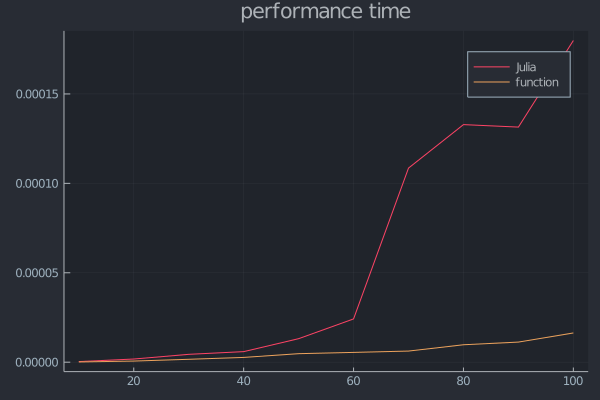

In [145]:
time_trace_function=[]
time_trace_julia=[]
for n in [10*i for i∈1:10]
    time_f=0
    time_j=0
    a=rand(n,n)
    b=rand(n,n)
    for i in 1:10
        time_f+= @belapsed Trace_calculator($a,$b)
        time_j+= @belapsed tr($a * $b)
    end
    push!(time_trace_function,time_f/10)
    push!(time_trace_julia,time_j/10)
end

we see that for smaller d the diffrence in compilation time is small, but as the dimention of matrix increases, our code performes much better relative to julia!

that is because we have compared the time it takes for julia to calculate product of matrices $\textbf{(A*B=AB)}$ and then find the trace. but in our code we just calculate the diagonal indexes of $\textbf{AB}$ and add them so it decreases the calculation load, resulting in smaller runtimes. 

here our code works better!

lets try again for much bigger dimentions:

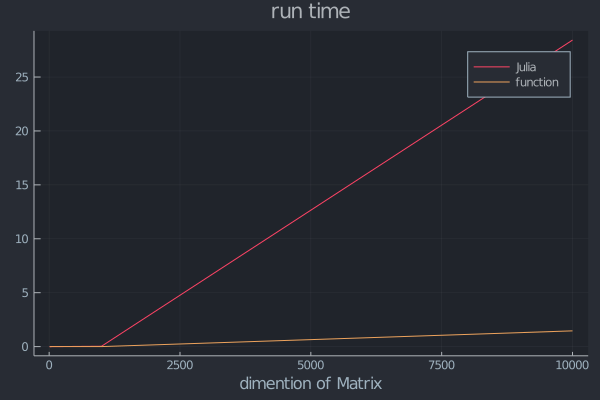

In [153]:
time_trace_function=[]
time_trace_julia=[]
for n in [10^i for i∈1:4]
    time_f=0
    time_j=0
    a=rand(n,n)
    b=rand(n,n)
    for i in 1:10
        time_f+= @belapsed Trace_calculator($a,$b)
        time_j+= @belapsed tr($a * $b)
    end
    push!(time_trace_function,time_f/10)
    push!(time_trace_julia,time_j/10)
end

p = plot([10^i for i∈1:4], time_trace_julia,xlabel="dimention of Matrix", label="Julia", title = "run time") 
plot!( p,[10^i for i∈1:4], time_trace_function , label="function")
p

again we see because of the extra calculations in $\textbf{A*B}$ with bigger dimentions the run time is much bigger! so again our code works better.

Problem 2

In [2]:
using IJulia 
using Pkg
IJulia.installkernel("Julia_8_threads", env=Dict("JULIA_NUM_THREADS"=>"8"))

┌ Info: Installing Julia_8_threads kernelspec in C:\Users\LENOVO\AppData\Roaming\jupyter\kernels\julia_8_threads-1.7
└ @ IJulia C:\Users\LENOVO\.julia\packages\IJulia\AQu2H\deps\kspec.jl:94


"C:\\Users\\LENOVO\\AppData\\Roaming\\jupyter\\kernels\\julia_8_threads-1.7"

In [2]:
using .Threads
nthreads()

8

In [162]:
function threaded_sum8(A,B)
    product=zeros(eltype(A),size(A)[1],size(B)[2]) #create an empty matrix the same size of product
    @threads for i in range(1,size(A)[1])
        @threads for j in range(1,size(B)[2])
            R = zeros(eltype(A), nthreads())
            @threads for k in range(1,size(A)[2])
                @inbounds R[threadid()] += A[i,k] * B[k,j]
            end
            for l in eachindex(R)
                @inbounds product[i,j] += R[l]
            end
        end
    end
    return product
end

function Test_2(n) #just a function to test the outcome
    A=rand(n,n)
    B=rand(n,n)
    if threaded_sum8(A,B) ≈ A*B
        println("The function works correctly")
    else 
        println("The function is wrong")
    end
end

Test_2 (generic function with 1 method)

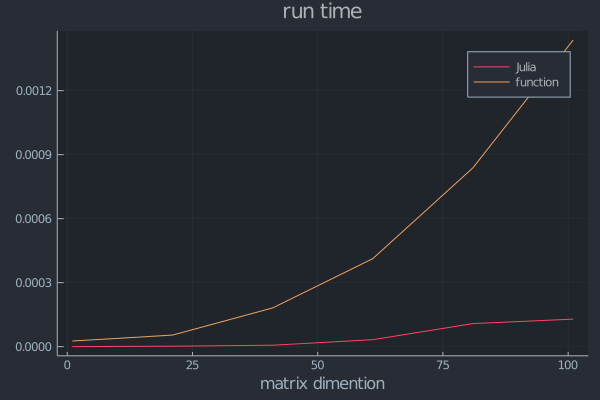

In [165]:
time_julia2=[]
time_function2=[]

for n in [1*(i+1)+19*i for i in 0:5]
    tjulia=0
    tfunction=0
    for i in range(1,10)
        A=rand(n,n)
        B=rand(n,n)
        tjulia+= @belapsed $A * $B
        tfunction+= @belapsed threaded_sum8($A,$B)
    end
    push!(time_julia2,tjulia/10)
    push!(time_function2,tfunction/10)
end

using Plots
theme(:juno)
p = plot([1*(i+1)+19*i for i in 0:5], time_julia2,xlabel="matrix dimention", label="Julia", title = "run time") 
plot!( p,[1*(i+1)+19*i for i in 0:5], time_function2 , label="function")
p

By comparing the matrix multiplication of julia and our program we see that julia has a noticeably shorter run time meaning it is more efficient. the diffrence in run time gets larger as the matrix dimention increases and our programs run time exponentialy increases (calculation load increases).

overall julias matrix multiplication has a better performance.

Problem 3:

In [3]:
import Random
const ThreadRNG = Vector{Random.MersenneTwister}(undef, nthreads())
@threads for i in 1:nthreads()
    ThreadRNG[Threads.threadid()] = Random.MersenneTwister()
end

In [6]:
function Area_calculator(n)
    inside = zeros(Int, nthreads())
    len, rem = divrem(n, nthreads())
    rem == 0 || error("use a multiple of $(nthreads()), please!")
    @threads for i in 1:nthreads()
        rng = ThreadRNG[threadid()]
        v = 0
        for j in 1:len
            x, y = rand(rng), rand(rng)
            v+= ((x^2 + y^2 <= 1) && ((x-1)^2 + (y-1)^2 <= 1) && ((x-1)^2 + y^2 <= 1) && (x^2 + (y-1)^2 <=1))
        end
        inside[threadid()] = v
    end
    return sum(inside) / n
end
println("area of the grey line is: ",Area_calculator(100_000_000))
#@time Area_calculator(100_000_000)

area of the grey line is: 0.31511665


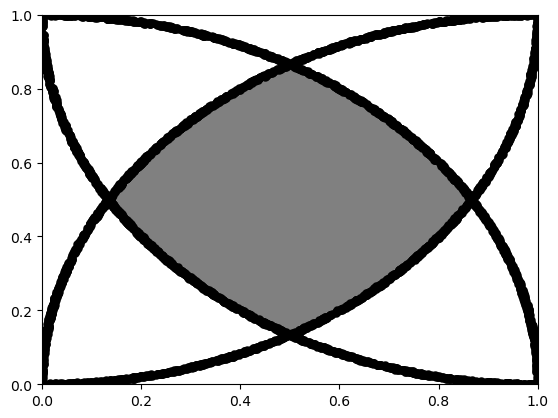

(0.0, 1.0)

In [5]:
#visualization
using  PyPlot
x_inside=[] ; y_inside=[] ; x_outside=[] ; y_outside=[] ; x_circle=[] ; y_circle=[]

function Area_calculator(n)
    v = 0
    for i in 1:n
        x, y = rand(), rand()
        if ((x^2 + y^2 <= 1) && ((x-1)^2 + (y-1)^2 <= 1) && ((x-1)^2 + y^2 <= 1) && (x^2 + (y-1)^2 <=1))
            v+=1
            push!(x_inside,x)
            push!(y_inside,y)
        else
            push!(x_outside,x)
            push!(y_outside,y)
        end
        if ((0.995 <x^2 + y^2 <1.005) || (0.995<(x-1)^2 + (y-1)^2 < 1.005) || (0.995<(x-1)^2 + y^2 <1.005) || (0.995< x^2 + (y-1)^2 <1.005))
            push!(x_circle,x)
            push!(y_circle,y)
        end
    end
    return v / n
end

Area_calculator(160000)
scatter(x_inside, y_inside, color="grey", linewidth=0.1)
scatter(x_circle, y_circle, color="black", linewidth=0.1)
#title("points inside vs points outside for $(total) points")
PyPlot.xlim(0,1)
PyPlot.ylim(0,1)

Problem 4

In [21]:
rng = ThreadRNG[threadid()] 
rand(rng)

0.6063107563642789

In [53]:
function threadedpi(n)
    inside = zeros(Int, nthreads())
    len, rem = divrem(n, nthreads())
    rem == 0 || error("use a multiple of $(nthreads()), please!")
    @threads for i in 1:nthreads()
        rng = ThreadRNG[threadid()]
        v = 0
        for j in 1:len
            x, theta = rand(rng), rand(rng)*π
            #println(x," ",1/2 *sin(theta) , " " , (( x+abs(1/2 *sin(theta)) <= 1)   && ( x-abs(1/2 * sin(theta))  >= 0)))
            v += (( x+abs(1/2 *sin(theta)) >= 1)   || ( x-abs(1/2 * sin(theta))  <= 0))
        end
        inside[threadid()] = v
    end
    return 2*n/sum(inside)
end
#threadedpi2(100_000_000)
@time threadedpi(100_000)

  0.083908 seconds (51.55 k allocations: 2.850 MiB, 97.55% compilation time)


3.1424306701233404

distributed implementation engages all cores(8 in this case) so performance of distributed implementation will be better than the normal form.

Problem 5

a) using static arrays for smaller arrays noticably decreases the runtime. for matrixes with less than 100 elements choosing static arrays can speed up the matrix multiplications by 5.9x the multiplication of normal matrices. StaticArrays uses abstract types to implement statically sized(the array size is part of the data type definition) arrays in Julia.  Subtypes of StaticArray will provide fast implementations of common array and linear algebra operations. 

In [20]:
using StaticArrays
using LinearAlgebra

m1=rand(5,5)
m2=rand(5,5)

M1=@SMatrix rand(5,5)
M2=@SMatrix rand(5,5)

time_julia5=[]
time_static_array5=[]

for n in [i for i in 1:10]
    jjulia= 0
    sstatic=0
    for i in 1:10
        m1 = rand(n,n)
        m2 = rand(n,n)
        #print(m1 * m2)
        jjulia+= @belapsed ($m1 * $m2)
        M1= SMatrix{n,n}(rand(n,n))
        M2= SMatrix{n,n}(rand(n,n))
        # M1=@SMatrix rand(n,n)
        # M2=@SMatrix rand(n,n)
        sstatic+= @belapsed ($M1*$M2)    
    end
    push!(time_julia5,jjulia/10)
    push!(time_static_array5,sstatic/10)
end


for small array sizes:

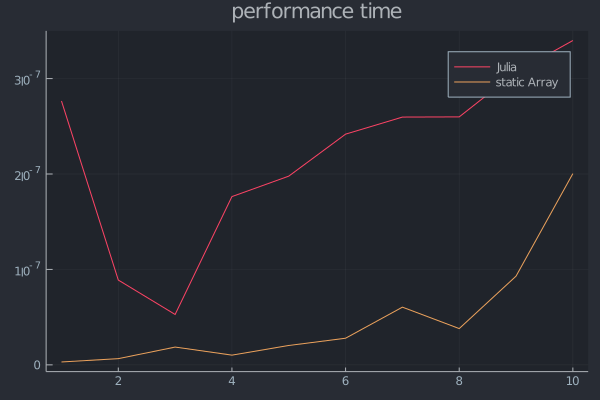

GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error


In [23]:
p = plot([i for i in 1:10], time_julia5, label="Julia", title = "performance time") 
plot!( p,[i for i in 1:10], time_static_array5 , label="static Array")
p

we run this code for matrices of sizes up to 30 and compare the diffrence in compilation time:

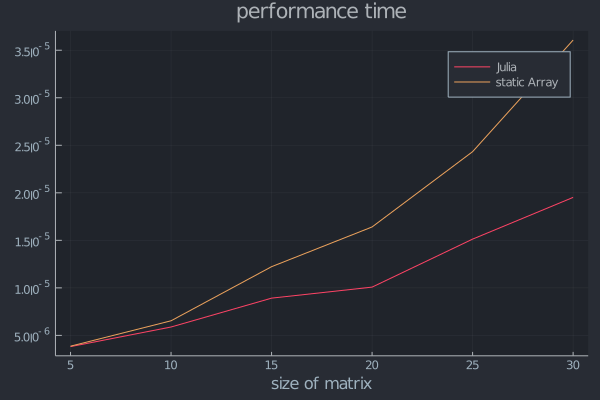

GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to un

In [19]:
# using Plots
# theme(:juno)
p = plot([5*i for i in 1:6], time_julia5,xlabel="size of matrix" ,label="Julia", title = "performance time") 
plot!( p,[5*i for i in 1:6], time_static_array5 , label="static Array")
p

we see that as the array size increases the performance of the static arrays gets worse than the normal arrays and the normal arrays are prefered.

Problem 6:

a) Yeppp's vectorized log is 3x faster than the one than the normal julia log.

In [ ]:
using Yeppp

x = rand(10^7)
ty = @elapsed Yeppp.log!(similar(x), x)
t  = @elapsed log(x)